#### Resume Classifier

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

Load dataset

In [11]:
df=pd.read_csv('UpdatedResumeDataSet.csv')
df.sample()

,Category,Resume
398,Java Developer,"Computer Skills: Languages And Script: JSP, Se..."


In [12]:
print(df.iloc[0,1])

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute Services   Assur

In [13]:
from sklearn.model_selection import train_test_split
X=df['Resume']
y=df['Category']
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

<Axes: xlabel='count', ylabel='Category'>

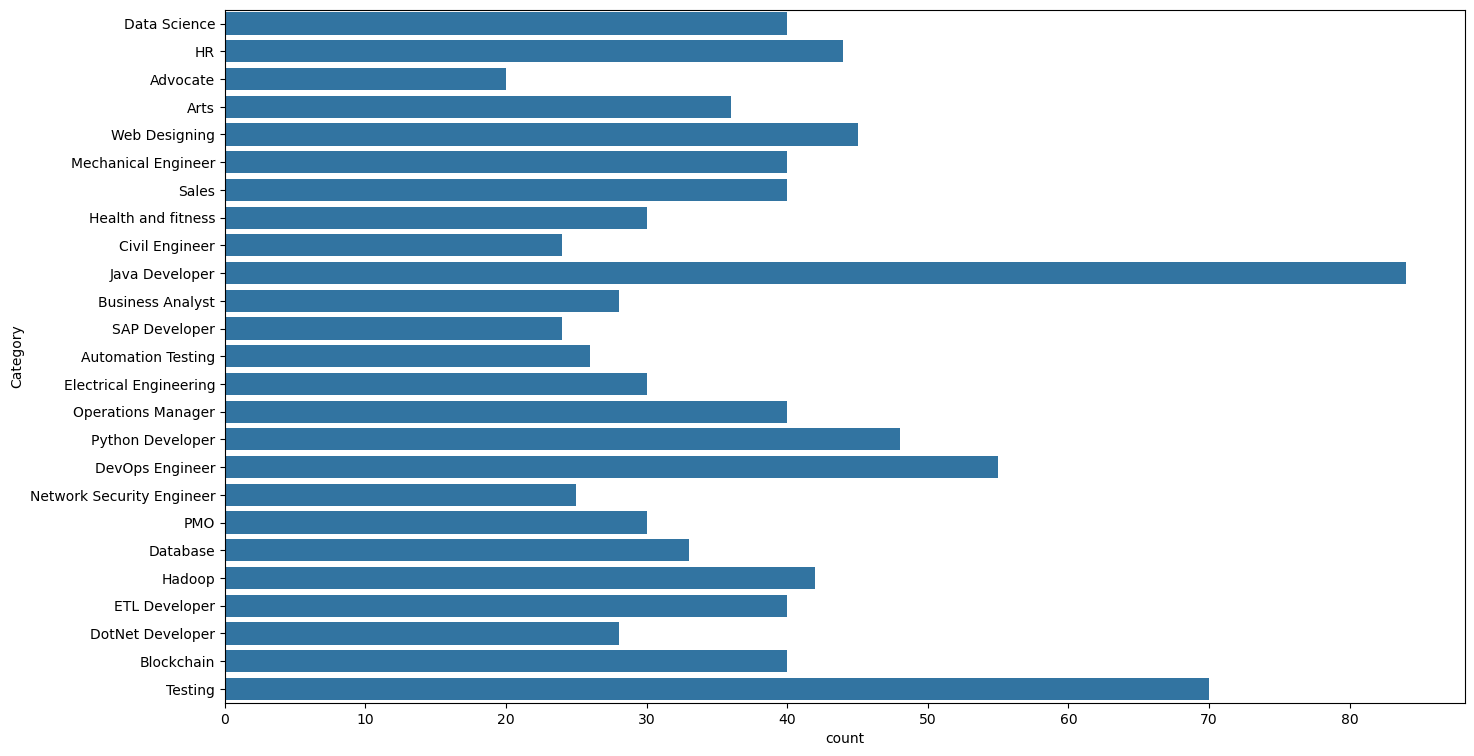

In [14]:
plt.figure(figsize=(16,9))
sns.countplot(y=y)

<Axes: ylabel='count'>

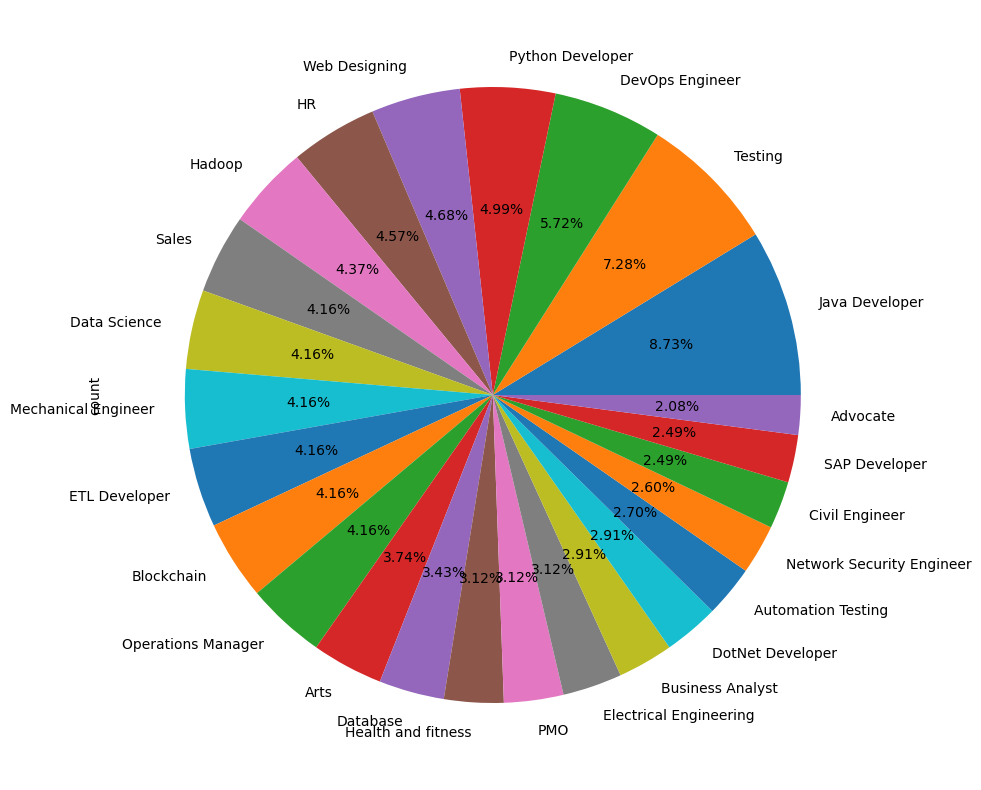

In [15]:
plt.figure(figsize=(10,10))
y.value_counts().plot(kind='pie',autopct='%1.2f%%')

Define the cleaning function

In [16]:
import re, string

In [17]:
def cleanResume(text):
    text=re.sub(r'http\S+\s*',' ',text) #URLS
    text=re.sub('RT|cc',' ',text) #RT / CC
    text=re.sub(r'#\S+',' ',text) # Remove hashtag
    text=re.sub(r'@\S+',' ',text) #remove mentions
    text=re.sub('[%s]'%re.escape(string.punctuation),' ',text) #punctuation
    text=re.sub(r'[^x\00-\x7f]',' ',text) 
    text=re.sub(r'\s+',' ',text) #
    return text

In [18]:
sent='हॅलो @Mahesh how are you?\nHave you seen https://fb.com #trend?'

In [19]:
cleanResume(sent)

' how are you Have you seen '

In [20]:
print(cleanResume(X[3]))

Skills R Python SAP HANA Tableau SAP HANA SQL SAP HANA PAL MS SQL SAP Lumira C Linear Programming Data Modelling Advance Analytics SCM Analytics Retail Analytics Social Media Analytics NLP Education Details January 2017 to January 2018 PGDM Business Analytics Great Lakes Institute of Management Illinois Institute of Technology January 2013 Bachelor of Engineering Electronics and Communication Bengaluru Karnataka New Horizon College of Engineering Bangalore Visvesvaraya Technological University Data Science Consultant Consultant Deloitte USI Skill Details LINEAR PROGRAMMING Exprience 6 months RETAIL Exprience 6 months RETAIL MARKETING Exprience 6 months SCM Exprience 6 months SQL Exprience Less than 1 year months Deep Learning Exprience Less than 1 year months Machine learning Exprience Less than 1 year months Python Exprience Less than 1 year months R Exprience Less than 1 year monthsCompany Details company Deloitte USI description The project involved analysing historic deals and comi

In [21]:
cleaned=X.apply(cleanResume)

In [22]:
cleaned

0      Skills Programming Languages Python pandas num...
1      Education Details May 2013 to May 2017 B E UIT...
2      Areas of Interest Deep Learning Control System...
3      Skills R Python SAP HANA Tableau SAP HANA SQL ...
4      Education Details MCA YMCAUST Faridabad Haryan...
                             ...                        
957    Computer Skills Proficient in MS office Word B...
958     Willingness to a ept the challenges Positive ...
959    PERSONAL SKILLS Quick learner Eagerness to lea...
960    COMPUTER SKILLS SOFTWARE KNOWLEDGE MS Power Po...
961    Skill Set OS Windows XP 7 8 8 1 10 Database MY...
Name: Resume, Length: 962, dtype: object

In [23]:
# to add all words sentence togather
cleaned_data=cleaned.sum()

In [24]:
print(len(cleaned_data))

2803381


In [25]:
# %pip install wordcloud -U

In [26]:
from wordcloud import WordCloud

In [27]:
cloud=WordCloud(max_words=100,background_color='white',collocations=False).generate(cleaned_data)

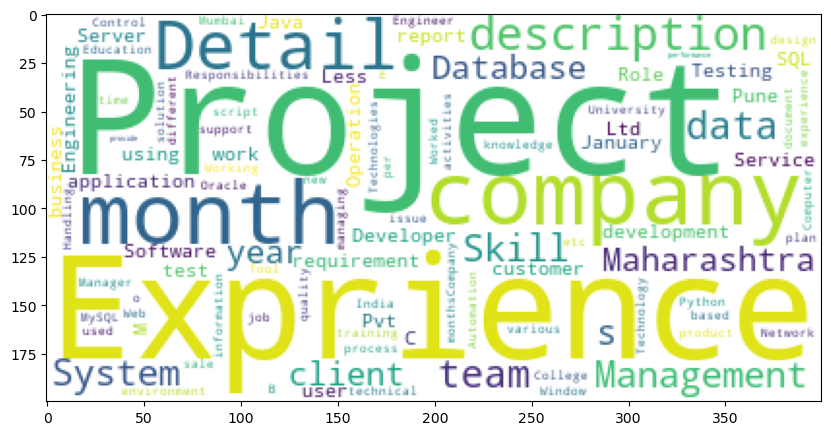

In [28]:
plt.figure(figsize=(10,10))
plt.imshow(cloud)

In [29]:
from nltk.tokenize import word_tokenize

In [30]:
pd.Series(word_tokenize(cleaned_data)).value_counts()

and                        16516
the                        10809
of                          8594
to                          7263
in                          5276
                           ...  
physicaltherapy                1
hiu                            1
7cees                          1
Golwin                         1
ADMINISTRATIONTECHNICAL        1
Name: count, Length: 10177, dtype: int64

In [31]:
word_tokenize(cleaned_data).count('Skill')

1007

In [32]:
new_data=' '.join(word_tokenize(cleaned_data))

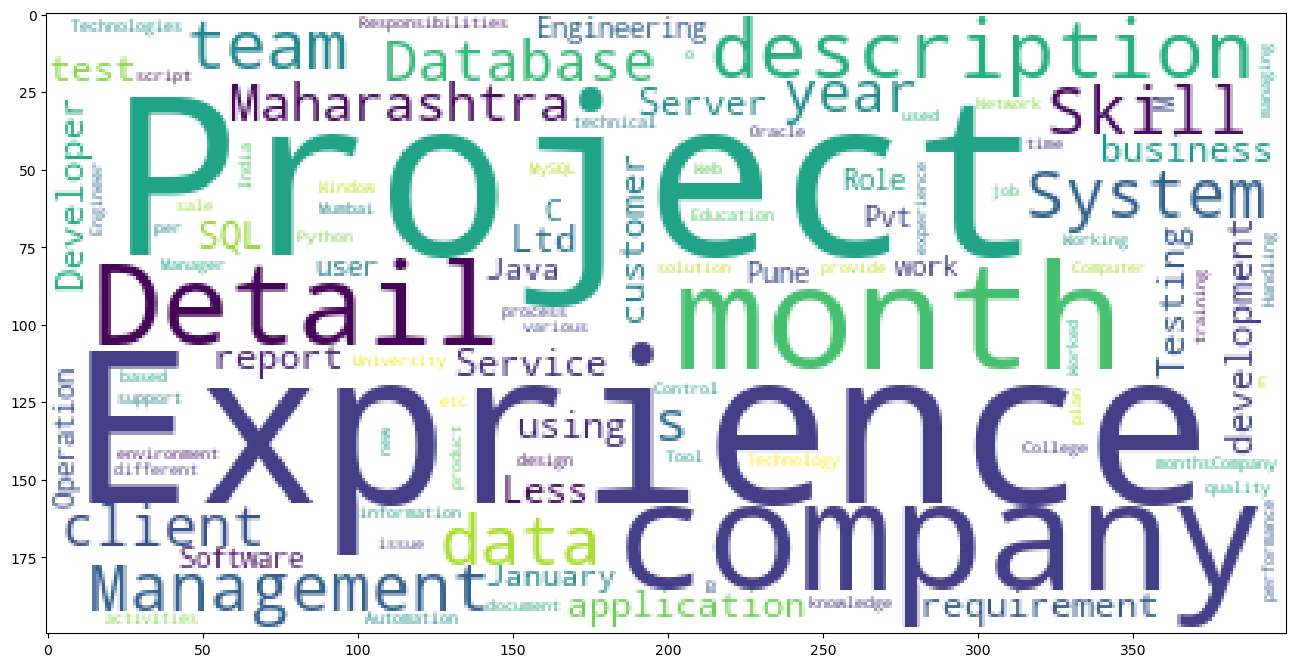

In [33]:
wcloud=WordCloud(max_words=100,background_color='white',collocations=False).generate(new_data)
plt.figure(figsize=(16,9))
plt.imshow(wcloud)

In [34]:
wcloud.words_

{'Project': 1.0,
 'Exprience': 0.9405551461557357,
 'company': 0.8779169737165315,
 'month': 0.8214197985752886,
 'Detail': 0.7693441414885778,
 'description': 0.7668877425693933,
 'team': 0.5303365266519283,
 'data': 0.5251780889216409,
 'Management': 0.4971751412429379,
 'Skill': 0.48882338491771066,
 'System': 0.47752394988946206,
 's': 0.4092360599361336,
 'Database': 0.3765659543109801,
 'year': 0.3682141979857529,
 'client': 0.3601080815524441,
 'Maharashtra': 0.3559322033898305,
 'application': 0.3424220093343159,
 'Service': 0.3377548513878654,
 'Testing': 0.33136821419798573,
 'test': 0.31859493981822645,
 'requirement': 0.3129452223041022,
 'report': 0.30189142716777206,
 'development': 0.29575042986981087,
 'business': 0.2937853107344633,
 'Server': 0.2937853107344633,
 'Developer': 0.2932940309506264,
 'customer': 0.28936379267993123,
 'Ltd': 0.2891181527880128,
 'Less': 0.28125767624662246,
 'using': 0.27609923851633505,
 'SQL': 0.27511667894866126,
 'January': 0.267747482

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
tfidf=TfidfVectorizer(stop_words='english')

In [37]:
X_new=tfidf.fit_transform(cleaned)

In [38]:
tfidf.get_feature_names_out()

array(['000', '01', '017', ..., 'zone', 'zookeeper', 'zz'], dtype=object)

In [39]:
# crross validations

In [40]:
from sklearn.neighbors import NearestCentroid

In [41]:
nc=NearestCentroid()

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X_new,y,random_state=0,test_size=0.2)

In [43]:
nc.fit(X_train,y_train)


c:\Users\PGCP-AI\AppData\Local\anaconda3\Lib\site-packages\sklearn\neighbors\_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(


,metric,'euclidean'
,shrink_threshold,None
,priors,'uniform'


In [44]:
y_pred=nc.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [46]:
print(accuracy_score(y_test,y_pred))

0.9896373056994818


In [47]:
print(confusion_matrix(y_test,y_pred))

[[ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1
   0]
 [ 0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   1]
 [ 0  0  0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  5

In [48]:
print(classification_report(y_test,y_pred))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         3
       Automation Testing       1.00      0.80      0.89         5
               Blockchain       1.00      1.00      1.00         9
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         9
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         9
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         9
                       HR       1.00      1.00      1.00         5
                   Hadoop       1.00      1.00      1.00     

#### new data prediction

In [49]:
f=open('Sample_resume.txt')
resume=f.read()

In [50]:
resume

'Tejashree Pishe \nJr. Machine Learning Engineer. (MITU Research) \nEXPERIENCE \nMITU Research, New Sangavi, Pune \n Feb 2021 till date \nHiko Technology Pvt. Ltd., Baner, Pune Full Time Internship \nAugust 2019 May 2020. \n \nKEY PROJECTS \nPredictive Analytics Implemented for Pistachio Types over quality parameter database\nStudy the origin, trade business and nutritional values over Pistachio types.\nReview the quality of pistachio types over its quality  \npararameters.\nCritically evaluate and data preprocessing over the database.\nUsed the Resampling techniques to work on imbalanced data set.\nIdentify the quality parameters which has more impact on classification of Pistachio types by quantitative analysis.\nFind out the best suitable algorithm with more than 90% accuracy to predict the type of pistachio over new data.\nUpdating and upgrading the model with non-predictable data.\nTechnologies: Python for Data Science, NumPY, Panda,\nMachine Learning Algorithms \n \nDesign and de

In [51]:
resume=tfidf.transform([resume])

In [52]:
nc.predict(resume)

array(['Data Science'], dtype=object)

predict on docx spp file

In [53]:
import docx

In [54]:
doc=docx.Document("spp.docx")

In [55]:
data=''
for para in doc.paragraphs:
    data+=para.text

In [56]:
data

'Mr. Satish Prakashrao PiseEmail – satish.pise.sgp@gmail.com\t\t\t\tContact No. 9096679875,7768962144ObjectiveWork with professional organization and contribute my excellent work with result oriented performance for continuous improvement in quality and development.  Experience – 6.3 YearsCurrent working in Sanjay Ghodawat Polytechnic, Kolhapur.Post-Lecturer Duration- 4.3 years, 1st June 2013 to till dateResponsibilities - Teaching, guiding, motivating students as a class teacher, lecturer, and working as a lab in-charge, spoken tutorial project, IIT Bombay coordinator.Organizing and conducting trainings for students.Subject Taught – RDBMS, CNE, CMF, CHM, CHN, NMA, LPR, DLS, GUI, BWP.Samarth Polytechnic Belhe, PunePost-Lecturer(Ad-hoc)Duration-8months, August 2012 to April 2013Responsibilities – Teaching.Subject Taught – CMF, MIS, MANLate. N.B. Chhabada Institute of Engineering and Technology, SataraPost-Lecturer(Ad-hoc) Duration-1 year, August 2011 to July 2012Responsibilities - Teach

In [57]:
resume=tfidf.transform([data])

In [58]:
nc.predict(resume)

array(['Arts'], dtype=object)